<a href="https://colab.research.google.com/github/mw2304/SummerProject2026/blob/main/probablisticCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting annihilation probability over position

1. Loadings

In [1]:
%pip install uproot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.2/401.2 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 989.5/989.5 kB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 692.5/692.5 kB 61.4 MB/s eta 0:00:00


In [2]:
%pip install awkward_pandas

In [3]:

import os
import numpy as np
import pandas as pd
import uproot

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    Flatten,
    Concatenate
)

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [4]:

ROOT_FILE = "augmerged.root"

file = uproot.open(ROOT_FILE)

print(file.keys())

['TwoG_NCS;1', 'TwoG_PhantomSCS;1', 'TwoG_ScannerSCS;1', 'TwoG_PhantomSCS_ScannerSCS;1', 'TwoG_PhantomDCS;1', 'TwoG_ScannerDCS;1', 'TwoG_PhantomSCS_ScannerDCS;1', 'TwoG_PhantomDCS_ScannerSCS;1', 'TwoG_PhantomDCS_ScannerDCS;1', 'TwoG_MCS;1', 'TwoG_Excluded;1', 'ThreeG_NCS;1', 'ThreeG_ScannerSCS;1', 'ThreeG_ScannerDCS;1', 'ThreeG_ScannerTCS;1', 'ThreeG_MCS;1', 'ThreeG_Excluded;1', 'Run;1']


In [5]:
tree = file["ThreeG_NCS"]
print(tree.keys())

['RunID', 'EventID', 'NGammas', 'AnnihilX_mm', 'AnnihilY_mm', 'AnnihilZ_mm', 'GammaIndex', 'GammaTrackID', 'GammaParentID', 'HitIndex', 'VolumeID', 'VolumeName', 'ProcessID', 'ProcessName', 'EnergyDeposit_keV', 'PreEnergy_keV', 'PostEnergy_keV', 'X_mm', 'Y_mm', 'Z_mm', 'Theta_deg', 'Phi_deg', 'DeltaPhi01_deg', 'DeltaPhi02_deg', 'DeltaPhi12_deg']


2. Branches for Three gamma NCS

In [6]:
branches = [

    "RunID",
    "EventID",

    "GammaIndex",
    'NGammas',

    "X_mm",
    "Y_mm",
    "Z_mm",

    "EnergyDeposit_keV",
    "PreEnergy_keV",
    "PostEnergy_keV",

    "AnnihilX_mm",
    "AnnihilY_mm",
    "AnnihilZ_mm"

]

tree = file["ThreeG_NCS"]
df = tree.arrays(branches, library="pd")

print(df.head())

              RunID  EventID  GammaIndex  NGammas       X_mm       Y_mm  \
0  slurm_36283167_1       43           0        3  22.533781  45.725643   
1  slurm_36283167_1       43           1        3 -19.154974 -41.295967   
2  slurm_36283167_1       43           2        3  10.009033  22.802109   
3  slurm_36283167_1       56           0        3  15.187184  14.526692   
4  slurm_36283167_1       56           1        3   1.183054 -10.753192   

        Z_mm  EnergyDeposit_keV  PreEnergy_keV  PostEnergy_keV  AnnihilX_mm  \
0  -6.039716         187.380234     187.380234             0.0     3.079860   
1  42.954437         471.598907     471.598907             0.0     3.079860   
2 -44.240387         363.018677     363.018677             0.0     3.079860   
3  46.622974         492.708618     492.708618             0.0    -0.369778   
4 -51.622868         304.623718     304.623718             0.0    -0.369778   

   AnnihilY_mm  AnnihilZ_mm  
0     6.565360    -6.969770  
1     6.565360

In [7]:
IMG_SIZE = 64

xmin = df.X_mm.min()
xmax = df.X_mm.max()

ymin = df.Y_mm.min()
ymax = df.Y_mm.max()

zmin = df.Z_mm.min()
zmax = df.Z_mm.max()

print(xmin, xmax)
print(ymin, ymax)
print(zmin, zmax)

-99.15685272216797 95.1434555053711
-92.13552856445312 96.26758575439453
-95.55072784423828 98.47635650634766


In [8]:

images = []
targets = []
plane_features = []

event_groups = df.groupby(["RunID", "EventID"], sort=False)



print(f"Building images from {event_groups.ngroups} events...")


for i, ((run_id, event_id), event) in enumerate(event_groups):

   #defining vector plane
    points = event.sort_values("GammaIndex")[["X_mm", "Y_mm", "Z_mm"]].values

    if len(points) != 3:
        continue

    P1 = points[0]
    P2 = points[1]
    P3 = points[2]

    # two vectors in the plane
    v1 = P2 - P1
    v2 = P3 - P1

    # plane normal
    normal = np.cross(v1, v2)

    # normalise and store
    if np.linalg.norm(normal) == 0:
        continue

    normal = normal / np.linalg.norm(normal)
    #plane_features.append(normal)

    # plane equation
    A, B, C = normal
    D = -np.dot(normal, P1)

    plane_features.append([A,B,C,D])



    # all hits with this RunID and EventID belong to one event

    image = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)


    # Channel 0: XY projection

    H_xy, _, _ = np.histogram2d(
        event["X_mm"],
        event["Y_mm"],
        bins=IMG_SIZE,
        range=[[xmin, xmax], [ymin, ymax]],
        weights=event["EnergyDeposit_keV"]
    )

    image[:, :, 0] = H_xy



    # Channel 1: XZ projection

    H_xz, _, _ = np.histogram2d(
        event["X_mm"],
        event["Z_mm"],
        bins=IMG_SIZE,
        range=[[xmin, xmax], [zmin, zmax]],
        weights=event["EnergyDeposit_keV"]
    )

    image[:, :, 1] = H_xz



    # Channel 2: YZ projection

    H_yz, _, _ = np.histogram2d(
        event["Y_mm"],
        event["Z_mm"],
        bins=IMG_SIZE,
        range=[[ymin, ymax], [zmin, zmax]],
        weights=event["EnergyDeposit_keV"]
    )

    image[:, :, 2] = H_yz

    # Regression Targets


    annihil_x = event["AnnihilX_mm"].iloc[0]
    annihil_y = event["AnnihilY_mm"].iloc[0]
    annihil_z = event["AnnihilZ_mm"].iloc[0]

    target = [
        annihil_x,
        annihil_y,
        annihil_z,
    ]



    # Store image and target


    images.append(image)
    targets.append(target)
    #plane_features.append(normal)

    if (i + 1) % 1000 == 0:
        print(f"{i+1} events processed")


# Convert lists to arrays
images = np.array(images, dtype=np.float16)
targets = np.array(targets, dtype=np.float32)
plane_features = np.array(plane_features, dtype=np.float32)

print()
print("Images shape :", images.shape)
print("Targets shape:", targets.shape)
print("Plane features shape:", plane_features.shape)


Building images from 18591 events...
1000 events processed
2000 events processed
3000 events processed
4000 events processed
5000 events processed
6000 events processed
7000 events processed
8000 events processed
9000 events processed
10000 events processed
11000 events processed
12000 events processed
13000 events processed
14000 events processed
15000 events processed
16000 events processed
17000 events processed
18000 events processed

Images shape : (18591, 64, 64, 3)
Targets shape: (18591, 3)
Plane features shape: (18591, 4)


Image normalisation

In [9]:
images /= np.max(images)

print(images.min())
print(images.max())

0.0
1.0


train test split

In [10]:
from sklearn.model_selection import train_test_split

x_train, x_temp, y_train, y_temp, plane_train, plane_temp = train_test_split(
    images,
    targets,
    plane_features,
    test_size=0.3,
    random_state=42,
    shuffle=True
)


print("Training images:", x_train.shape)
print("Temporary images:", x_temp.shape)

print("Training targets:", y_train.shape)
print("Temporary targets:", y_temp.shape)

print("Training planes:", plane_train.shape)
print("Temporary planes:", plane_temp.shape)

Training images: (13013, 64, 64, 3)
Temporary images: (5578, 64, 64, 3)
Training targets: (13013, 3)
Temporary targets: (5578, 3)
Training planes: (13013, 4)
Temporary planes: (5578, 4)


In [11]:
x_val, x_test, y_val, y_test, plane_val, plane_test = train_test_split(
    x_temp,
    y_temp,
    plane_temp,
    test_size=0.5,
    random_state=42,
    shuffle=True
)


print("Train:")
print(x_train.shape, y_train.shape, plane_train.shape)

print("\nValidation:")
print(x_val.shape, y_val.shape, plane_val.shape)

print("\nTest:")
print(x_test.shape, y_test.shape, plane_test.shape)

Train:
(13013, 64, 64, 3) (13013, 3) (13013, 4)

Validation:
(2789, 64, 64, 3) (2789, 3) (2789, 4)

Test:
(2789, 64, 64, 3) (2789, 3) (2789, 4)


scaler

In [12]:
from sklearn.preprocessing import StandardScaler

target_scaler = StandardScaler()

# Fit only on training coordinates
y_train_scaled = target_scaler.fit_transform(y_train)

# Apply same transformation
y_val_scaled = target_scaler.transform(y_val)
y_test_scaled = target_scaler.transform(y_test)

print("Original:")
print(y_train[0])

print("\nNormalised:")
print(y_train_scaled[0])

print("\nTraining mean:")
print(target_scaler.mean_)

print("\nTraining standard deviation:")
print(target_scaler.scale_)

Original:
[ 1.4491183  6.338306  -9.167334 ]

Normalised:
[-0.18592414  1.2884794  -0.5519326 ]

Training mean:
[ 1.82113887  3.0061665  -8.12768961]

Training standard deviation:
[2.00092689 2.58610211 1.88364315]


In [12]:
from sklearn.preprocessing import StandardScaler

target_scaler = StandardScaler()

y_train_scaled = target_scaler.fit_transform(y_train)

y_test_scaled = target_scaler.transform(y_test)


print(y_train_scaled[0])

[-0.18592414  1.2884794  -0.5519326 ]


building cnn

In [13]:
# Image input

image_input = Input(
    shape=(64,64,3),
    name="detector_image"
)


# First convolution block

x = Conv2D(
    16,
    (3,3),
    activation="relu"
)(image_input)

x = MaxPooling2D()(x)



# Second convolution block

x = Conv2D(
    32,
    (3,3),
    activation="relu"
)(x)

x = MaxPooling2D()(x)



# Third convolution block

x = Conv2D(
    64,
    (3,3),
    activation="relu"
)(x)

x = MaxPooling2D()(x)



# Convert feature maps into vector

x = Flatten()(x)

# Plane input

plane_input = Input(
    shape=(4,),
    name="plane_equation"
)


plane_features = Dense(
    16,
    activation="relu"
)(plane_input)

#Combining CNN and plane info
combined = Concatenate()(
    [x, plane_features]
)

#fully connected layers
combined = Dense(
    128,
    activation="relu"
)(combined)


combined = Dropout(0.3)(combined)
output = Dense(3)(combined)




In [14]:
model = Model(
    inputs=[
         image_input,
        plane_input
    ],
     outputs=output
)

In [15]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ detector_image      │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 62, 62,    │        448 │ detector_image[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 31, 31,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 29, 29,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 14, 14,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 12, 12,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 6, 6, 64)  │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ plane_equation      │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 2304)      │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │         80 │ plane_equation[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2320)      │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    297,088 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 3)         │        387 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 321,139 (1.23 MB)

 Trainable params: 321,139 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

IGNORE CELL defining probabilotic loss functions

In [ ]:
def gaussian_nll(y_true, y_pred):

    # Split predictions into mean and uncertainty

    mu = y_pred[:, :3]      # predicted x,y,z
    sigma = y_pred[:, 3:]   # predicted uncertainty


    # Prevent sigma becoming negative or zero
    sigma = tf.nn.softplus(sigma) + 1e-6


    # Gaussian negative log likelihood
    loss = (
        0.5 * tf.square((y_true - mu) / sigma)
        + tf.math.log(sigma)
    )


    # Average over x,y,z
    return tf.reduce_mean(loss)

In [ ]:
lambda_plane = 0.1  # start small

def gaussian_nll_with_plane(y_true, y_pred, plane):

    # Predicted mean and uncertainty
    mu = y_pred[:, :3]
    sigma = y_pred[:, 3:]

    sigma = tf.nn.softplus(sigma) + 1e-6

    # Gaussian negative log likelihood
    nll = (
        0.5 * tf.square((y_true - mu) / sigma)
        + tf.math.log(sigma)
    )
    nll = tf.reduce_mean(nll)

    # Plane coefficients
    A = plane[:,0]
    B = plane[:,1]
    C = plane[:,2]
    D = plane[:,3]

    # Distance from predicted point to plane
    plane_residual = (
        A*mu[:,0] +
        B*mu[:,1] +
        C*mu[:,2] +
        D
    )

    plane_loss = tf.reduce_mean(tf.square(plane_residual))

    return nll + lambda_plane * plane_loss

compiling model

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="mse",
    metrics=["mae"]
)

training model

In [17]:
history = model.fit(
    [x_train, plane_train],
    y_train,
    validation_data=(
        [x_val, plane_val],
        y_val
    ),
    epochs=50,
    batch_size=32
)

Epoch 1/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 8.2968 - mae: 2.2357 - val_loss: 4.6807 - val_mae: 1.7999
Epoch 2/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.1119 - mae: 1.8743 - val_loss: 4.5714 - val_mae: 1.7757
Epoch 3/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4.9836 - mae: 1.8462 - val_loss: 4.5242 - val_mae: 1.7631
Epoch 4/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 4.8748 - mae: 1.8238 - val_loss: 4.4094 - val_mae: 1.7369
Epoch 5/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4.7537 - mae: 1.8031 - val_loss: 4.3292 - val_mae: 1.7185
Epoch 6/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4.6447 - mae: 1.7803 - val_loss: 4.2479 - val_mae: 1.6993
Epoch 7/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4.5642 - mae: 1.7581 - val_loss: 4.0921 - val_mae: 1.6658
Epoch 8/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4.3913 - mae: 1.7226 - val_loss: 3.9857 - val_mae: 1.6435
Epoch 9/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - 

In [17]:
history = model.fit(
    [x_train, plane_train],
    y_train_scaled,
    validation_data=(
        [x_val, plane_val],
        y_val_scaled
    ),
    epochs=50,
    batch_size=32
)

Epoch 1/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - loss: 0.9661 - mae: 0.8217 - val_loss: 0.9221 - val_mae: 0.8009
Epoch 2/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.9008 - mae: 0.7910 - val_loss: 0.8587 - val_mae: 0.7702
Epoch 3/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.8395 - mae: 0.7577 - val_loss: 0.8129 - val_mae: 0.7427
Epoch 4/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.7888 - mae: 0.7294 - val_loss: 0.7641 - val_mae: 0.7180
Epoch 5/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7564 - mae: 0.7103 - val_loss: 0.7381 - val_mae: 0.7037
Epoch 6/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.7300 - mae: 0.6961 - val_loss: 0.7184 - val_mae: 0.6920
Epoch 7/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7083 - mae: 0.6831 - val_loss: 0.7022 - val_mae: 0.6840
Epoch 8/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6939 - mae: 0.6758 - val_loss: 0.6877 - val_mae: 0.6754
Epoch 9/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - 

plotting loss

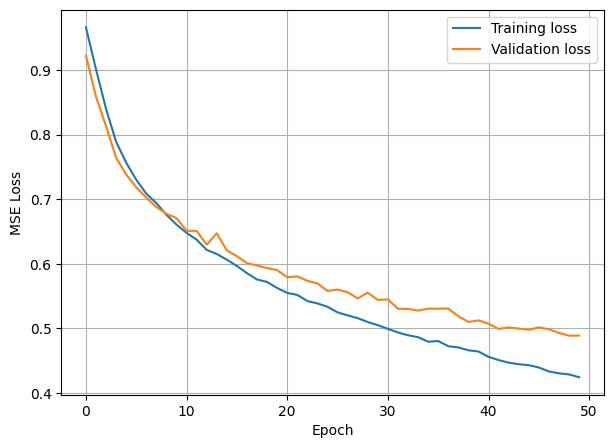

In [18]:
import matplotlib.pyplot as plt


plt.figure(figsize=(7,5))

plt.plot(
    history.history["loss"],
    label="Training loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()
plt.show()

making predictions

In [19]:
prediction = model.predict(
    [
        x_test,
        plane_test
    ]
)
print(prediction.shape)

88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
(2789, 3)


In [19]:
prediction_scaled = model.predict(
    [
        x_test,
        plane_test
    ]
)

prediction = target_scaler.inverse_transform(
    prediction_scaled
)

print("Scaled prediction shape:", prediction_scaled.shape)
print("Prediction shape:", prediction.shape)

88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Scaled prediction shape: (2789, 3)
Prediction shape: (2789, 3)


In [20]:
normal = plane_test[:, :3]

D = plane_test[:, 3]

distance = (
    np.sum(normal * prediction, axis=1) + D
)

prediction_on_plane = (
    prediction
    - distance[:, None] * normal
)

In [21]:
from sklearn.metrics import mean_absolute_error

mae_original = mean_absolute_error(
    y_test,
    prediction
)

mae_projected = mean_absolute_error(
    y_test,
    prediction_on_plane
)

print("Original CNN MAE:",
      mae_original,
      "mm")

print("Plane-projected MAE:",
      mae_projected,
      "mm")

Original CNN MAE: 1.1958036422729492 mm
Plane-projected MAE: 1.106608510017395 mm


In [22]:
original_error = prediction - y_test

projected_error = prediction_on_plane - y_test


original_distance = np.sqrt(
    np.sum(original_error**2, axis=1)
)

projected_distance = np.sqrt(
    np.sum(projected_error**2, axis=1)
)


print("Mean 3D reconstruction error BEFORE projection:",
      np.mean(original_distance),
      "mm")

print("Mean 3D reconstruction error AFTER projection:",
      np.mean(projected_distance),
      "mm")

Mean 3D reconstruction error BEFORE projection: 2.4045217 mm
Mean 3D reconstruction error AFTER projection: 2.2138362 mm


In [23]:
print("Median 3D error BEFORE projection:",
      np.median(original_distance),
      "mm")

print("Median 3D error AFTER projection:",
      np.median(projected_distance),
      "mm")

Median 3D error BEFORE projection: 2.2412374 mm
Median 3D error AFTER projection: 2.0630634 mm


In [24]:
projected_plane_distance = (
    np.sum(
        normal * prediction_on_plane,
        axis=1
    )
    + D
)

print(
    "Mean distance of projected predictions from plane:",
    np.mean(np.abs(projected_plane_distance)),
    "mm"
)

Mean distance of projected predictions from plane: 1.8403021e-07 mm


In [25]:
print("\n===== CNN PERFORMANCE =====")

print(
    "MAE before projection:",
    mae_original,
    "mm"
)

print(
    "MAE after projection:",
    mae_projected,
    "mm"
)

print(
    "Mean 3D error before projection:",
    np.mean(original_distance),
    "mm"
)

print(
    "Mean 3D error after projection:",
    np.mean(projected_distance),
    "mm"
)

print(
    "Median 3D error before projection:",
    np.median(original_distance),
    "mm"
)

print(
    "Median 3D error after projection:",
    np.median(projected_distance),
    "mm"
)


===== CNN PERFORMANCE =====
MAE before projection: 1.1958036422729492 mm
MAE after projection: 1.106608510017395 mm
Mean 3D error before projection: 2.4045217 mm
Mean 3D error after projection: 2.2138362 mm
Median 3D error before projection: 2.2412374 mm
Median 3D error after projection: 2.0630634 mm


NameError: name 'true_point' is not defined

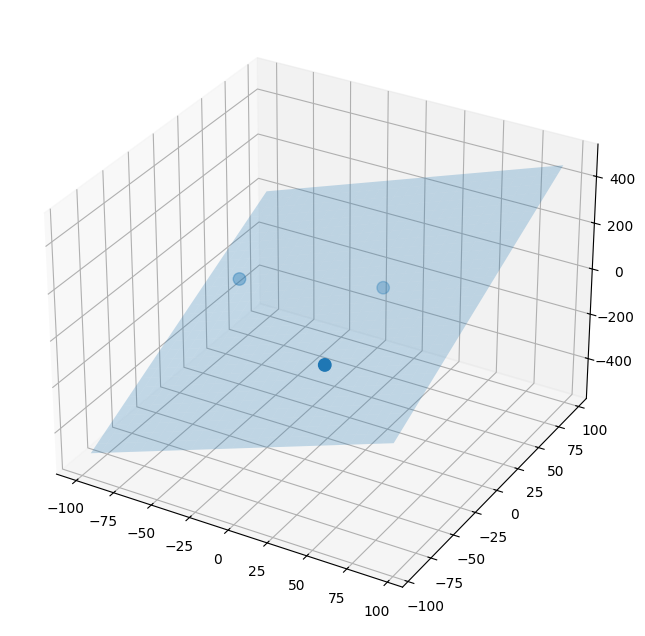

In [28]:
event = 0

A, B, C, D = plane_test[event]

# Create grid around detector hits
x_range = np.linspace(
    xmin,
    xmax,
    30
)

y_range = np.linspace(
    ymin,
    ymax,
    30
)

X, Y = np.meshgrid(
    x_range,
    y_range
)

Z = -(A*X + B*Y + D) / C

fig = plt.figure(figsize=(9, 8))

ax = fig.add_subplot(
    111,
    projection="3d"
)

# Plane
ax.plot_surface(
    X,
    Y,
    Z,
    alpha=0.25
)

# Detector hits
ax.scatter(
    points[:,0],
    points[:,1],
    points[:,2],
    s=80,
    label="Detector hits"
)

# True annihilation
ax.scatter(
    true_point[0],
    true_point[1],
    true_point[2],
    s=120,
    marker="*",
    label="True annihilation"
)

# Original CNN
ax.scatter(
    pred_point[0],
    pred_point[1],
    pred_point[2],
    s=100,
    marker="x",
    label="CNN prediction"
)

# Projected CNN
ax.scatter(
    projected_point[0],
    projected_point[1],
    projected_point[2],
    s=100,
    marker="^",
    label="Projected prediction"
)

ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_zlabel("Z (mm)")

ax.set_title(
    "Detector-Hit Plane and CNN Reconstruction"
)

ax.legend()

plt.show()

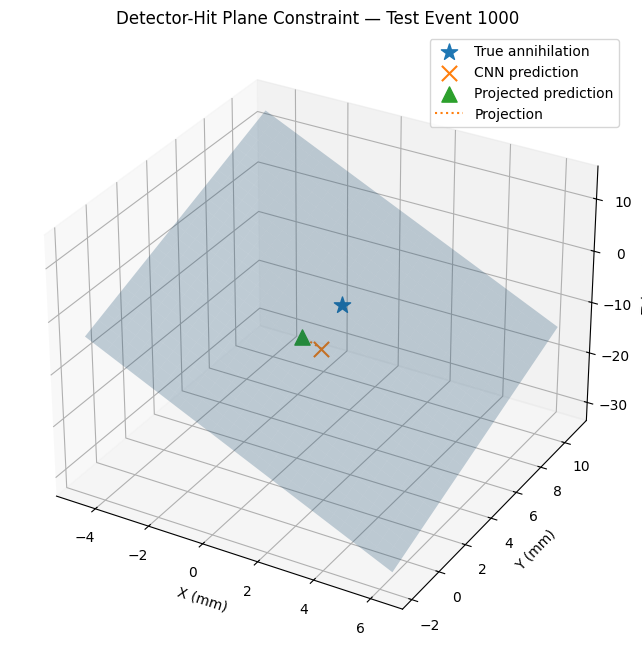

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Choose a test event
event = 1000

# ---------------------------------------
# Get plane coefficients
# ---------------------------------------

A, B, C, D = plane_test[event]

# ---------------------------------------
# Get true and predicted positions
# ---------------------------------------

true_point = y_test[event]

pred_point = prediction[event]

projected_point = prediction_on_plane[event]

# ---------------------------------------
# Create a grid for the plane
# ---------------------------------------

# Centre the plane around the points of interest
all_points = np.vstack([
    true_point,
    pred_point,
    projected_point
])

x_min = all_points[:, 0].min() - 5
x_max = all_points[:, 0].max() + 5

y_min = all_points[:, 1].min() - 5
y_max = all_points[:, 1].max() + 5

x_range = np.linspace(x_min, x_max, 30)
y_range = np.linspace(y_min, y_max, 30)

X, Y = np.meshgrid(x_range, y_range)

# ---------------------------------------
# Calculate Z from plane equation
# Ax + By + Cz + D = 0
# ---------------------------------------

if abs(C) > 1e-10:

    Z = -(A * X + B * Y + D) / C

else:
    print("C is too close to zero.")
    Z = np.zeros_like(X)

# ---------------------------------------
# Plot
# ---------------------------------------

fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(
    111,
    projection="3d"
)

# Plane
ax.plot_surface(
    X,
    Y,
    Z,
    alpha=0.25
)

# True annihilation position
ax.scatter(
    true_point[0],
    true_point[1],
    true_point[2],
    s=150,
    marker="*",
    label="True annihilation"
)

# Original CNN prediction
ax.scatter(
    pred_point[0],
    pred_point[1],
    pred_point[2],
    s=120,
    marker="x",
    label="CNN prediction"
)

# Projected prediction
ax.scatter(
    projected_point[0],
    projected_point[1],
    projected_point[2],
    s=120,
    marker="^",
    label="Projected prediction"
)

# Projection line
ax.plot(
    [pred_point[0], projected_point[0]],
    [pred_point[1], projected_point[1]],
    [pred_point[2], projected_point[2]],
    linestyle=":",
    label="Projection"
)

# Labels
ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_zlabel("Z (mm)")

ax.set_title(
    f"Detector-Hit Plane Constraint — Test Event {event}"
)

ax.legend()

plt.show()

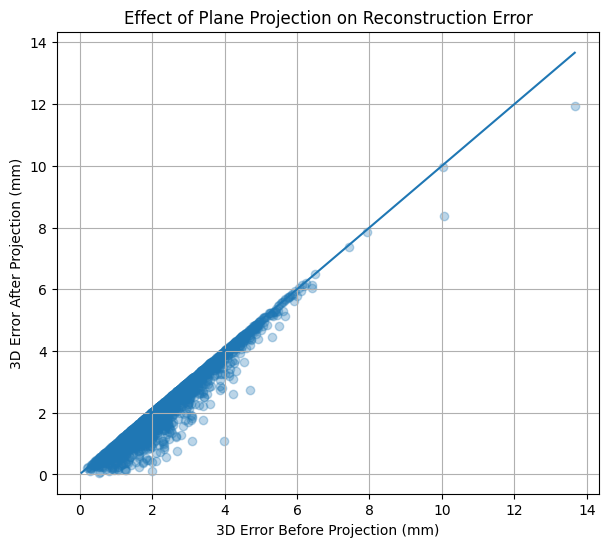

In [33]:
plt.figure(figsize=(7,6))

plt.scatter(
    original_distance,
    projected_distance,
    alpha=0.3
)

minimum = min(
    original_distance.min(),
    projected_distance.min()
)

maximum = max(
    original_distance.max(),
    projected_distance.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum]
)

plt.xlabel("3D Error Before Projection (mm)")
plt.ylabel("3D Error After Projection (mm)")

plt.title(
    "Effect of Plane Projection on Reconstruction Error"
)

plt.grid()
plt.show()

IGNORE BELOW

checking pred

In [ ]:
for i in range(5):

    print("Event", i)

    print(
        "True:",
        y_test[i]
    )

    print(
        "Predicted:",
        mu_mm[i]
    )

    print(
        "Uncertainty:",
        sigma_mm[i]
    )

    print()

Event 0
True: [ 1.1561439e+00  2.9678505e-03 -9.0266495e+00]


NameError: name 'mu_mm' is not defined

calculating position error and MAE

In [ ]:
position_error = mu_mm - y_test


distance_error = np.sqrt(
    position_error[:,0]**2 +
    position_error[:,1]**2 +
    position_error[:,2]**2
)


print(
    "Mean annihilation position error:",
    np.mean(distance_error),
    "mm"
)

Mean annihilation position error: 2.4495685 mm


In [ ]:
from sklearn.metrics import mean_absolute_error


mae_x = mean_absolute_error(
    y_test[:,0],
    mu_mm[:,0]
)

mae_y = mean_absolute_error(
    y_test[:,1],
    mu_mm[:,1]
)

mae_z = mean_absolute_error(
    y_test[:,2],
    mu_mm[:,2]
)


print("X MAE:", mae_x, "mm")
print("Y MAE:", mae_y, "mm")
print("Z MAE:", mae_z, "mm")

X MAE: 1.1208953857421875 mm
Y MAE: 1.4153200387954712 mm
Z MAE: 1.1167327165603638 mm


In [ ]:
average_uncertainty = np.mean(
    sigma_mm,
    axis=1
)


correlation = np.corrcoef(
    average_uncertainty,
    distance_error
)[0,1]


print(
    "Uncertainty-error correlation:",
    correlation
)

Uncertainty-error correlation: 0.5697584054237466


plot reconstuction

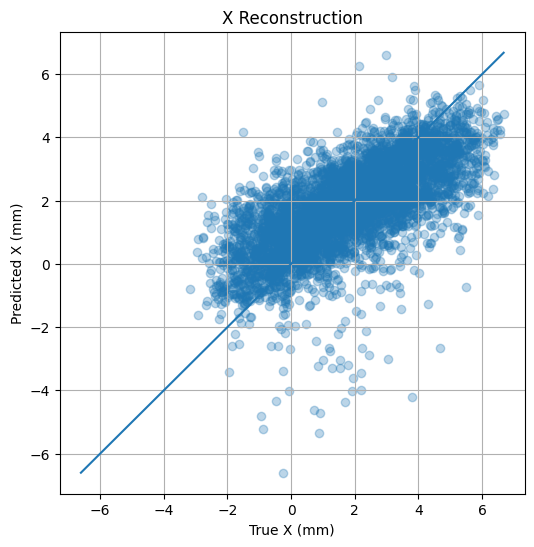

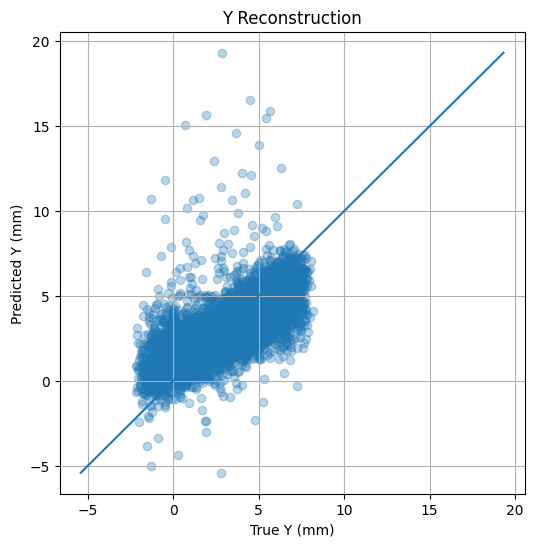

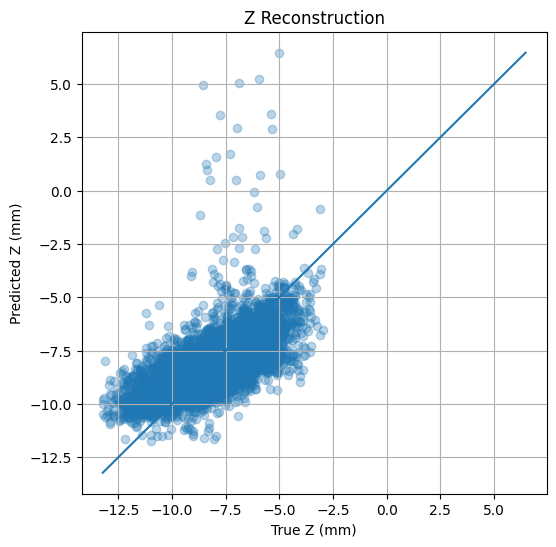

In [ ]:
import matplotlib.pyplot as plt


coordinates = ["X", "Y", "Z"]


for i, coord in enumerate(coordinates):

    plt.figure(figsize=(6,6))

    plt.scatter(
        y_test[:,i],
        mu_mm[:,i],
        alpha=0.3
    )

    # perfect prediction line
    minimum = min(
        y_test[:,i].min(),
        mu_mm[:,i].min()
    )

    maximum = max(
        y_test[:,i].max(),
        mu_mm[:,i].max()
    )

    plt.plot(
        [minimum, maximum],
        [minimum, maximum]
    )

    plt.xlabel(f"True {coord} (mm)")
    plt.ylabel(f"Predicted {coord} (mm)")
    plt.title(f"{coord} Reconstruction")

    plt.grid()
    plt.show()

residuals

In [ ]:
residuals = mu_mm - y_test

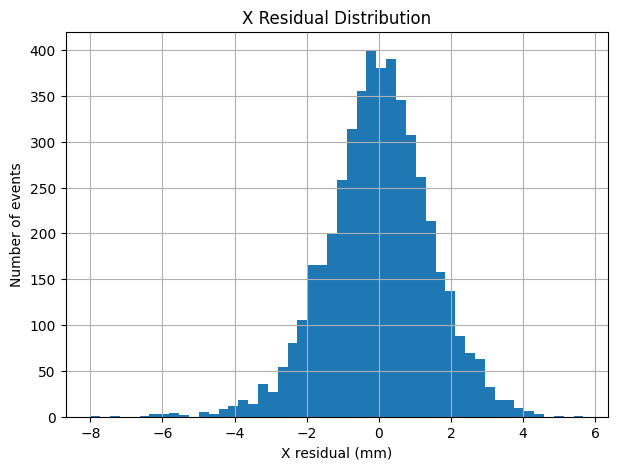

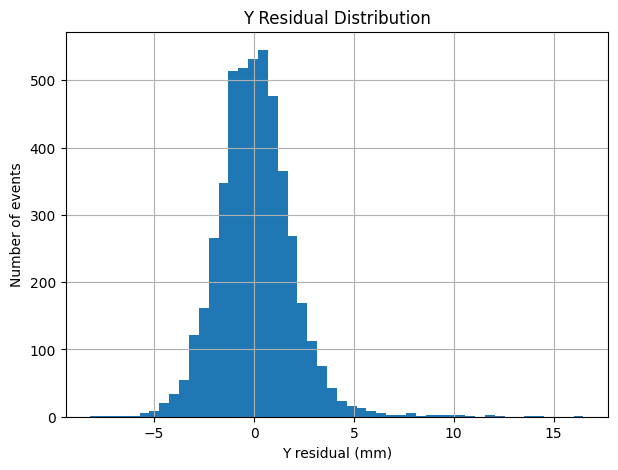

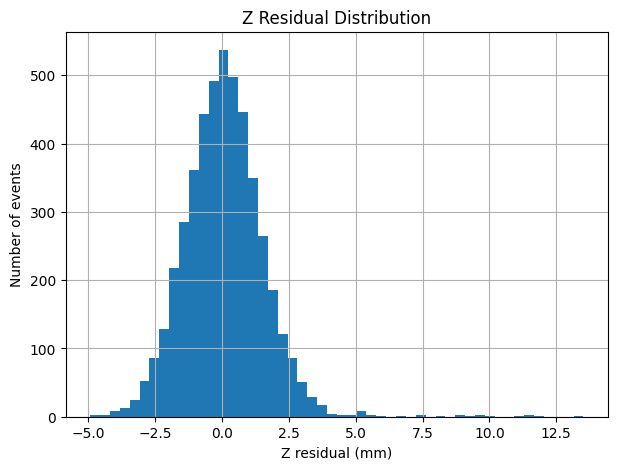

In [ ]:
for i, coord in enumerate(coordinates):

    plt.figure(figsize=(7,5))

    plt.hist(
        residuals[:,i],
        bins=50
    )

    plt.xlabel(
        f"{coord} residual (mm)"
    )

    plt.ylabel(
        "Number of events"
    )

    plt.title(
        f"{coord} Residual Distribution"
    )

    plt.grid()
    plt.show()

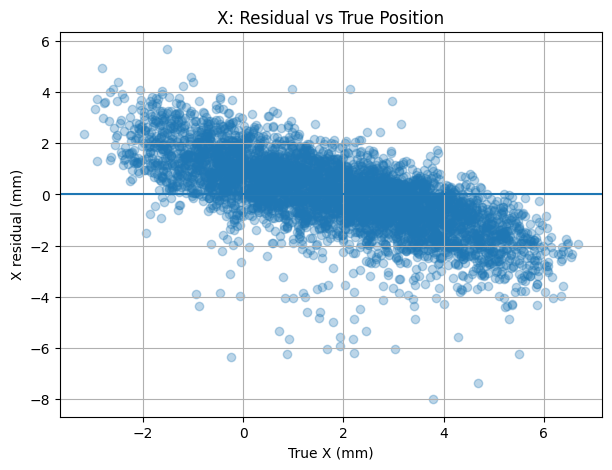

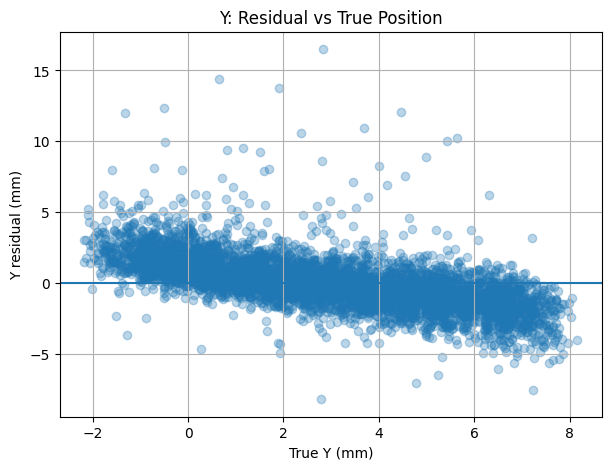

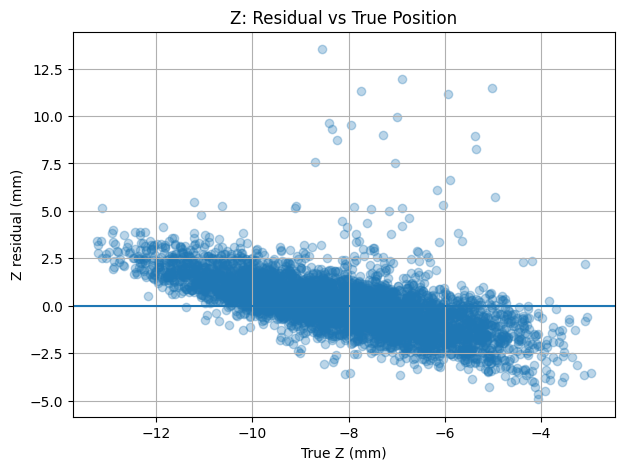

In [ ]:
for i, coord in enumerate(coordinates):

    plt.figure(figsize=(7,5))

    plt.scatter(
        y_test[:,i],
        residuals[:,i],
        alpha=0.3
    )

    plt.axhline(
        0
    )

    plt.xlabel(
        f"True {coord} (mm)"
    )

    plt.ylabel(
        f"{coord} residual (mm)"
    )

    plt.title(
        f"{coord}: Residual vs True Position"
    )

    plt.grid()
    plt.show()

uncenrtainity vs erorr

In [ ]:
mean_sigma = np.mean(
    sigma_mm,
    axis=1
)

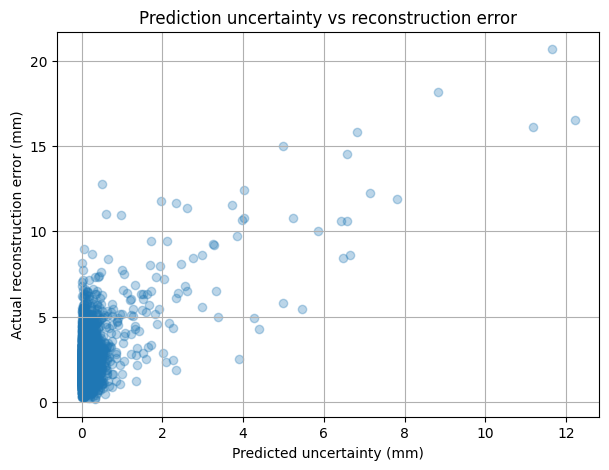

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(
    mean_sigma,
    distance_error,
    alpha=0.3
)

plt.xlabel(
    "Predicted uncertainty (mm)"
)

plt.ylabel(
    "Actual reconstruction error (mm)"
)

plt.title(
    "Prediction uncertainty vs reconstruction error"
)

plt.grid()
plt.show()

In [ ]:
print(
    "Mean 3D position error:",
    np.mean(distance_error),
    "mm"
)


print(
    "Median 3D position error:",
    np.median(distance_error),
    "mm"
)


print(
    "Mean uncertainty:",
    np.mean(mean_sigma),
    "mm"
)

Mean 3D position error: 2.4495685 mm
Median 3D position error: 2.2329543 mm
Mean uncertainty: 0.17646415526935635 mm


In [ ]:
for i in range(5):

    print("Event", i)

    print("Error:",
          distance_error[i],
          "mm")

    print("Uncertainty:",
          sigma_mm[i])

    print()

Event 0
Error: 1.4224803 mm
Uncertainty: [0.02534806 0.12704618 0.00715382]

Event 1
Error: 4.378827 mm
Uncertainty: [0.33385142 0.00972183 0.01323323]

Event 2
Error: 0.816648 mm
Uncertainty: [0.06610352 0.02963885 0.26607149]

Event 3
Error: 3.0224042 mm
Uncertainty: [0.06294645 0.66328573 0.17308489]

Event 4
Error: 2.2180133 mm
Uncertainty: [0.11790598 0.04179913 0.10846544]



In [ ]:
mean_sigma = np.mean(
    sigma_mm,
    axis=1
)

correlation = np.corrcoef(
    mean_sigma,
    distance_error
)[0,1]

print(
    "Uncertainty-error correlation:",
    correlation
)

Uncertainty-error correlation: 0.5697584054237466


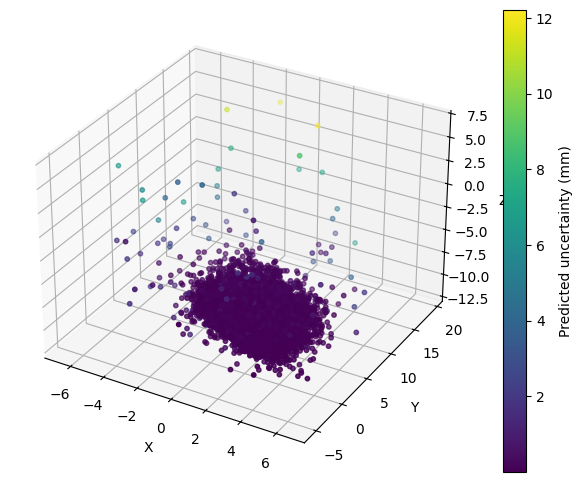

In [ ]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    mu_mm[:,0],
    mu_mm[:,1],
    mu_mm[:,2],
    c=mean_sigma,
    s=10
)

plt.colorbar(sc, label="Predicted uncertainty (mm)")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

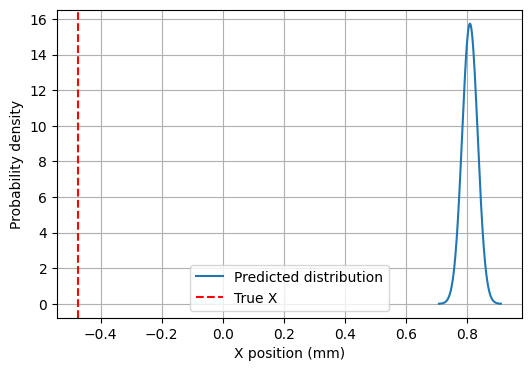

In [ ]:
event = 0

x = np.linspace(
    mu_mm[event,0]-4*sigma_mm[event,0],
    mu_mm[event,0]+4*sigma_mm[event,0],
    200
)

pdf = (
    1/(sigma_mm[event,0]*np.sqrt(2*np.pi))
    * np.exp(-(x-mu_mm[event,0])**2/(2*sigma_mm[event,0]**2))
)

plt.figure(figsize=(6,4))

plt.plot(x, pdf, label="Predicted distribution")

plt.axvline(
    y_test[event,0],
    color="red",
    linestyle="--",
    label="True X"
)

plt.xlabel("X position (mm)")
plt.ylabel("Probability density")

plt.legend()
plt.grid()

plt.show()

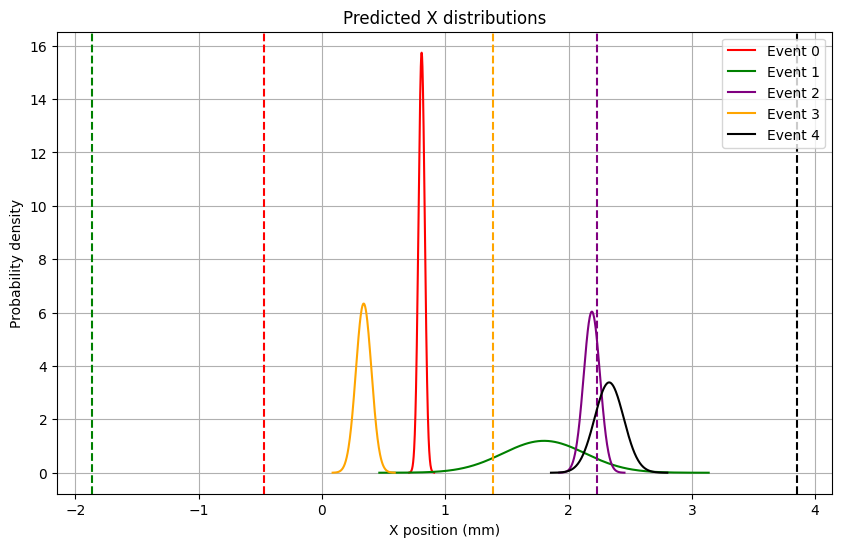

In [ ]:
plt.figure(figsize=(10,6))

events = [0, 1, 2, 3, 4]

colours = ["red", "green", "purple", "orange", "black"]

for event, colour in zip(events, colours):

    x = np.linspace(
        mu_mm[event,0] - 4*sigma_mm[event,0],
        mu_mm[event,0] + 4*sigma_mm[event,0],
        200
    )

    pdf = (
        1/(sigma_mm[event,0]*np.sqrt(2*np.pi))
        * np.exp(-(x-mu_mm[event,0])**2/(2*sigma_mm[event,0]**2))
    )

    # predicted distribution
    plt.plot(
        x,
        pdf,
        color=colour,
        label=f"Event {event}"
    )

    # true position (same colour, dashed)
    plt.axvline(
        y_test[event,0],
        color=colour,
        linestyle="--"
    )

plt.xlabel("X position (mm)")
plt.ylabel("Probability density")
plt.title("Predicted X distributions")

plt.legend()
plt.grid()
plt.show()

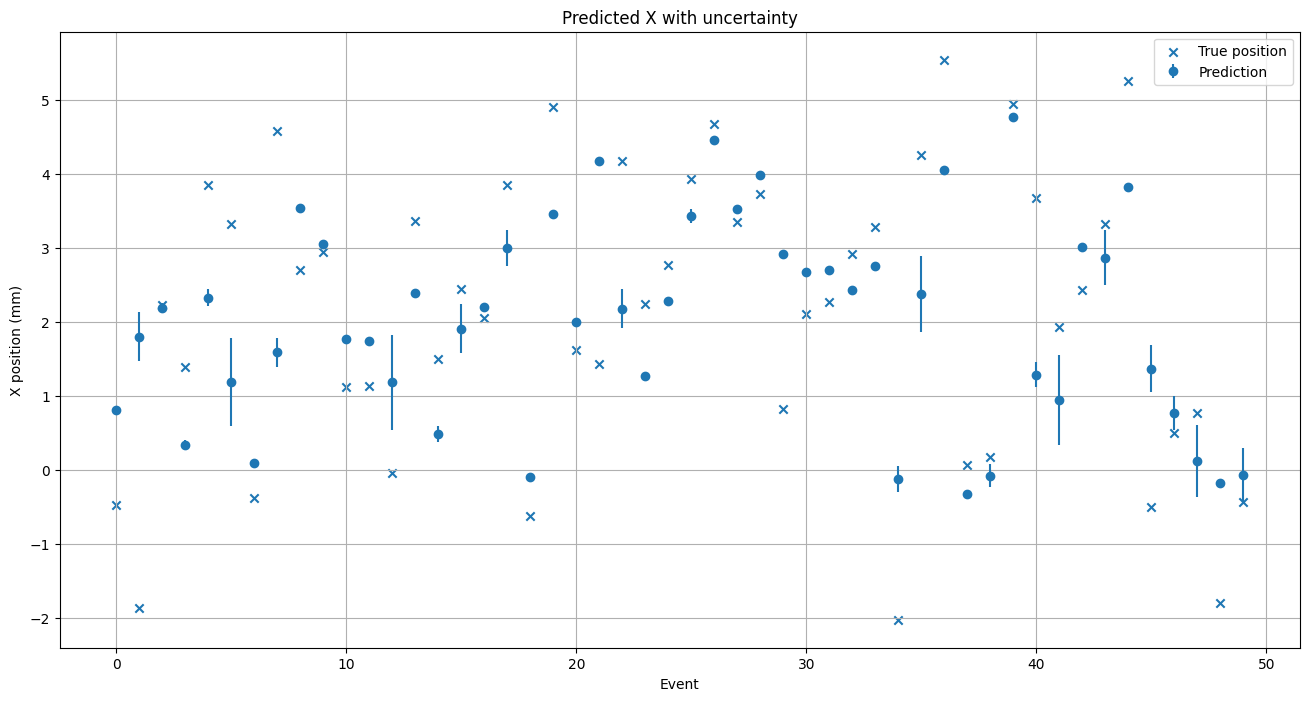

In [ ]:
idx = np.arange(50)

plt.figure(figsize=(16,8))

plt.errorbar(
    idx,
    mu_mm[:50,0],
    yerr=sigma_mm[:50,0],
    fmt='o',
    label="Prediction"
)

plt.scatter(
    idx,
    y_test[:50,0],
    marker='x',
    label="True position"
)

plt.xlabel("Event")
plt.ylabel("X position (mm)")
plt.title("Predicted X with uncertainty")
plt.legend()
plt.grid()
plt.show()